In [37]:
# Imports
from matplotlib.ticker import FixedLocator, FuncFormatter
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [38]:
# Load data
df = pd.read_csv('./data/FinalTransactionReport.csv')

In [39]:
# Examine columns in data
for col in df.columns:
    print(f"{col}: {df[col].dtype}")

Event Name: object
Event ID: int64
Event Timestamp: object
Venue Name: object
Transaction Timestamp: object
Price Scale: object
Section: object
Row: object
Seats: object
Primary Seat IDs: object
Average Unit Price: float64
Sales Total: float64
Tickets Sold: int64
Market Place: object
Transaction Type: object
Highest Inventory Price: float64
Lowest Inventory Price: float64
Initial Inventory Price: float64
Event Score: float64
weather_condition: object
temperature_f: float64
precipitation: float64
humidity: int64
weather_category: object
Days Before Event: int64
Start Time: object
Day of Week: object


In [40]:
df['Event Timestamp'].nunique()

66

In [41]:
team_summary = df.groupby('Event Name', as_index = False).agg(
    NumberOfGames = ('Event ID', 'nunique'),
    TicketsSold = ('Tickets Sold', 'sum'),
    TotalSales = ('Sales Total', 'sum'),
)

team_summary['TicketsPerGame'] = team_summary['TicketsSold'] / team_summary['NumberOfGames']
team_summary['SalesPerGame'] = team_summary['TotalSales'] / team_summary['NumberOfGames']
team_summary['Team Location'] = team_summary['Event Name'].apply(lambda x: x.split(' ')[0])

In [42]:
team_summary

,Event Name,NumberOfGames,TicketsSold,TotalSales,TicketsPerGame,SalesPerGame,Team Location
0,Carolina Mudcats,12,8658,169613.66,721.500000,14134.471667,Carolina
1,Charleston Riverdogs,6,3825,81722.18,637.500000,13620.363333,Charleston
2,Delmarva Shorebirds,9,9413,205186.75,1045.888889,22798.527778,Delmarva
3,Fayetteville Woodpeckers,12,7954,136479.93,662.833333,11373.327500,Fayetteville
4,Kannapolis Cannon Ballers,6,3637,71442.55,606.166667,11907.091667,Kannapolis
5,Lynchburg Hillcats,9,6840,144329.67,760.000000,16036.630000,Lynchburg
6,Salem Red Sox,12,7886,158817.67,657.166667,13234.805833,Salem


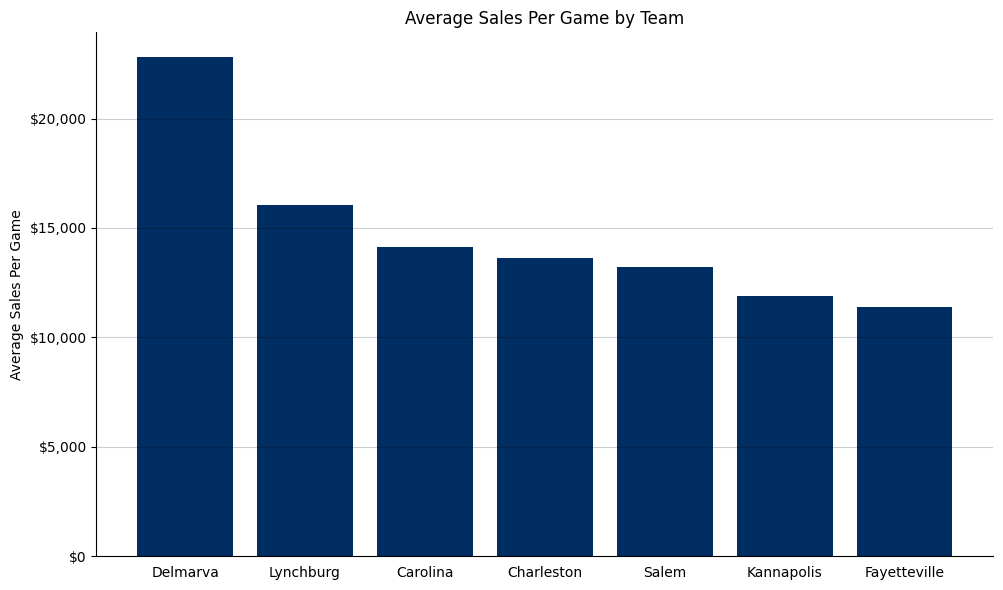

In [43]:
plt.figure(figsize = (10, 6))
team_summary.sort_values(by = 'SalesPerGame', ascending = False, inplace = True)
plt.bar(team_summary['Team Location'], team_summary['SalesPerGame'], color = '#002d62')
plt.ylabel('Average Sales Per Game')
plt.title('Average Sales Per Game by Team')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.tick_params(bottom = False, left = True)
plt.grid(axis = 'y', linestyle = '-', alpha = 0.2, color = 'black', zorder = 0)
plt.gca().yaxis.set_major_locator(FixedLocator(np.arange(0, 100000, 5000)))
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${x:,.0f}'))
plt.show()

In [44]:
start_time_summary = df.groupby('Start Time', as_index = False).agg(
    NumberOfGames = ('Event ID', 'nunique'),
    TicketsSold = ('Tickets Sold', 'sum'),
    TotalSales = ('Sales Total', 'sum'),
)

start_time_summary['TicketsPerGame'] = start_time_summary['TicketsSold'] / start_time_summary['NumberOfGames']
start_time_summary['SalesPerGame'] = start_time_summary['TotalSales'] / start_time_summary['NumberOfGames']

start_time_summary

,Start Time,NumberOfGames,TicketsSold,TotalSales,TicketsPerGame,SalesPerGame
0,11:05 AM,3,712,14201.79,237.333333,4733.930000
1,1:35 PM,7,7464,153491.54,1066.285714,21927.362857
2,6:05 PM,8,3364,67111.84,420.500000,8388.980000
3,6:35 PM,24,9496,168717.00,395.666667,7029.875000
4,7:05 PM,24,27177,564070.24,1132.375000,23502.926667


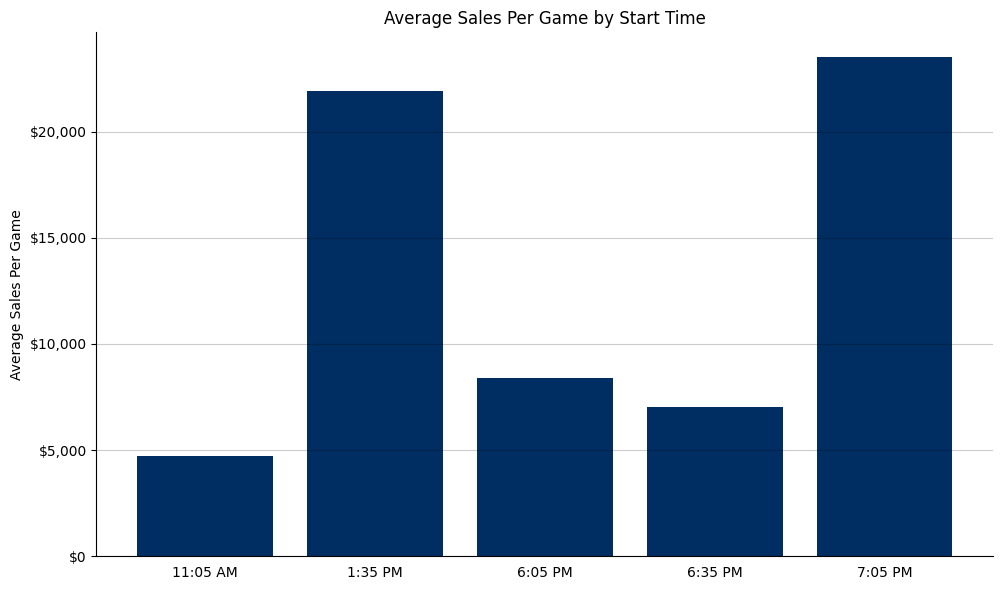

In [45]:
plt.figure(figsize = (10, 6))
start_time_summary.sort_values(by = 'Start Time', ascending = True, inplace = True)
plt.bar(start_time_summary['Start Time'], start_time_summary['SalesPerGame'], color = '#002d62')
plt.ylabel('Average Sales Per Game')
plt.title('Average Sales Per Game by Start Time')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.tick_params(bottom = False, left = True)
plt.grid(axis = 'y', linestyle = '-', alpha = 0.2, color = 'black', zorder = 0)
plt.gca().yaxis.set_major_locator(FixedLocator(np.arange(0, 100000, 5000)))
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${x:,.0f}'))
plt.show()

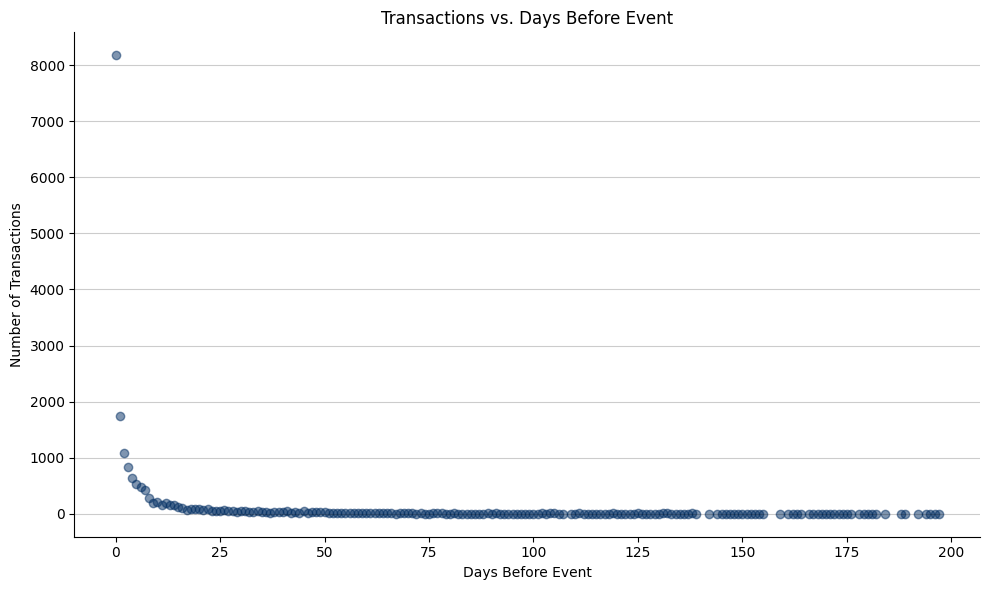

In [46]:
# Count transactions by Days Before Event
days_counts = df.groupby('Days Before Event').size().reset_index(name='Transactions')

plt.figure(figsize=(10, 6))
plt.scatter(days_counts['Days Before Event'], days_counts['Transactions'], alpha=0.5, color='#002d62')
plt.xlabel('Days Before Event')
plt.ylabel('Number of Transactions')
plt.title('Transactions vs. Days Before Event')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.grid(axis='y', linestyle='-', alpha=0.2, color='black', zorder=0)
plt.show()

In [47]:
day_summary = df.groupby('Day of Week', as_index = False).agg(
    NumberOfGames = ('Event ID', 'nunique'),
    TicketsSold = ('Tickets Sold', 'sum'),
    TotalSales = ('Sales Total', 'sum'),
)

day_summary['TicketsPerGame'] = day_summary['TicketsSold'] / day_summary['NumberOfGames']
day_summary['SalesPerGame'] = day_summary['TotalSales'] / day_summary['NumberOfGames']


day_summary

,Day of Week,NumberOfGames,TicketsSold,TotalSales,TicketsPerGame,SalesPerGame
0,Friday,12,12503,270451.11,1041.916667,22537.592500
1,Saturday,12,14674,293619.13,1222.833333,24468.260833
2,Sunday,12,10062,203790.88,838.500000,16982.573333
3,Thursday,10,3876,68744.81,387.600000,6874.481000
4,Tuesday,10,3624,79688.15,362.400000,7968.815000
5,Wednesday,10,3474,51298.33,347.400000,5129.833000


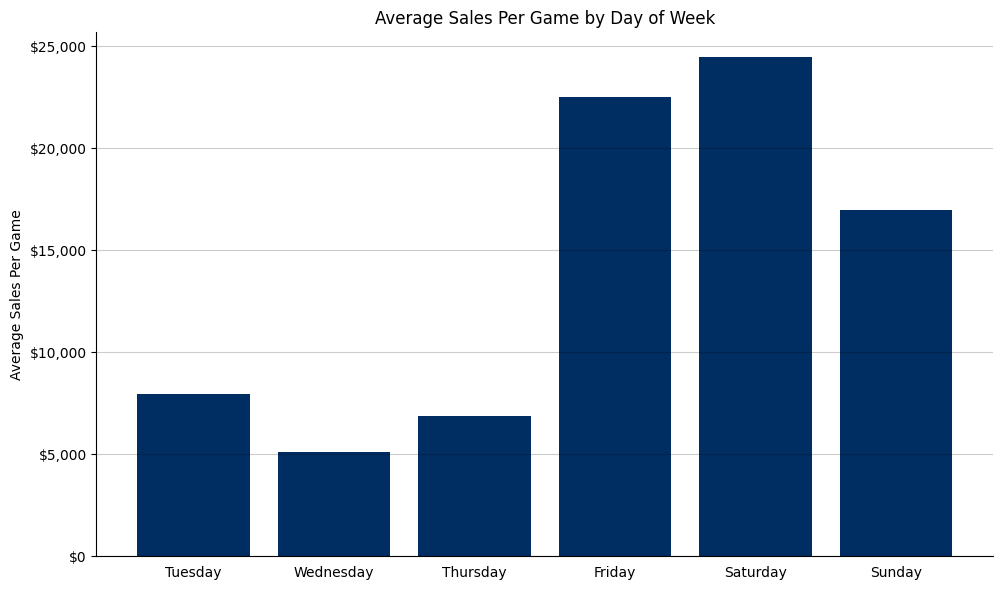

In [48]:
plt.figure(figsize = (10, 6))
# Order days of week correctly
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_summary['Day of Week'] = pd.Categorical(day_summary['Day of Week'], categories = day_order, ordered = True)
day_summary.sort_values(by = 'Day of Week', inplace = True) # Sort by day of week for plotting
plt.bar(day_summary['Day of Week'], day_summary['SalesPerGame'], color = '#002d62')
plt.ylabel('Average Sales Per Game')
plt.title('Average Sales Per Game by Day of Week')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.tick_params(bottom = False, left = True)
plt.grid(axis = 'y', linestyle = '-', alpha = 0.2, color = 'black', zorder = 0)
plt.gca().yaxis.set_major_locator(FixedLocator(np.arange(0, 100000, 5000)))
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${x:,.0f}'))
plt.show()

In [49]:
# Start time breakdown by day of week
start_time_day_summary = df.groupby(['Day of Week', 'Start Time'], as_index = False).agg(
    NumberOfGames = ('Event ID', 'nunique'),
    TicketsSold = ('Tickets Sold', 'sum'),
    TotalSales = ('Sales Total', 'sum'),
)  

start_time_day_summary['TicketsPerGame'] = start_time_day_summary['TicketsSold'] / start_time_day_summary['NumberOfGames']
start_time_day_summary['SalesPerGame'] = start_time_day_summary['TotalSales'] / start_time_day_summary['NumberOfGames']
start_time_day_summary

,Day of Week,Start Time,NumberOfGames,TicketsSold,TotalSales,TicketsPerGame,SalesPerGame
0,Friday,7:05 PM,12,12503,270451.11,1041.916667,22537.592500
1,Saturday,7:05 PM,12,14674,293619.13,1222.833333,24468.260833
2,Sunday,1:35 PM,7,7464,153491.54,1066.285714,21927.362857
3,Sunday,6:05 PM,5,2598,50299.34,519.600000,10059.868000
4,Thursday,6:35 PM,10,3876,68744.81,387.600000,6874.481000
5,Tuesday,6:05 PM,3,766,16812.50,255.333333,5604.166667
6,Tuesday,6:35 PM,7,2858,62875.65,408.285714,8982.235714
7,Wednesday,11:05 AM,3,712,14201.79,237.333333,4733.930000
8,Wednesday,6:35 PM,7,2762,37096.54,394.571429,5299.505714


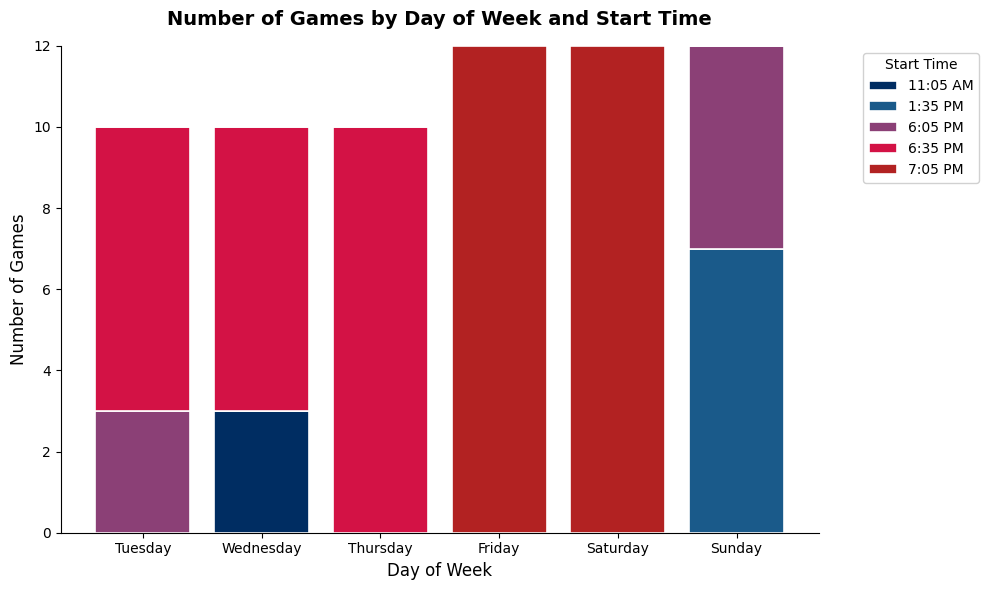

In [50]:
days_order = ['Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

unique_times = start_time_day_summary['Start Time'].unique()

# Sort times earliest to latest
time_order = sorted(unique_times, key=lambda t: pd.to_datetime(t, format='%I:%M %p'))

time_games = {}
for time in time_order:
    subset = start_time_day_summary[start_time_day_summary['Start Time'] == time]
    day_map = dict(zip(subset['Day of Week'], subset['NumberOfGames']))
    time_games[time] = [day_map.get(day, 0) for day in days_order]

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#ffffff')
ax.set_facecolor('#ffffff')

x = np.arange(len(days_order))
bottoms = np.zeros(len(days_order))

colors = ['#002d62', '#1a5a8a', '#8b4076', '#d31245', 'firebrick']

for i, (time, counts) in enumerate(time_games.items()):
    counts = np.array(counts)
    ax.bar(x, counts, bottom=bottoms, label=time, color=colors[i], edgecolor='white', linewidth=1.2)
    bottoms += counts

ax.set_xticks(x)
ax.set_xticklabels(days_order)
ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylabel('Number of Games', fontsize=12)
ax.set_title('Number of Games by Day of Week and Start Time', fontsize=14, pad=15, fontweight='bold')
ax.legend(title='Start Time', bbox_to_anchor=(1.05, 1), loc='upper left', framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()